![QuantConnect Logo](https://cdn.quantconnect.com/web/i/icon.png)
<hr>

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
qb = QuantBook()

In [4]:
tickers = ["JPM", "BAC", "MS", "SCHW", "GS", "AXP", "C"]
symbols = [qb.add_equity(ticker, Resolution.DAILY).symbol for ticker in tickers]

In [9]:
pe_ratios = qb.get_fundamental(symbols, "ValuationRatios.PERatio", datetime(2016, 1, 1), datetime(2026, 1, 1))
pe_ratios.head()

,AXP R735QTJ8XC9X,CMB R735QTJ8XC9X,GS RKEOGCOG6RFP,MWD R735QTJ8XC9X,NB R735QTJ8XC9X,SCH R735QTJ8XC9X,TRV R735QTJ8XC9X
2016-01-05,12.554152,11.229592,11.841656,19.396341,12.466667,33.262626,11.629213
2016-01-06,12.554152,11.229592,11.841656,19.396341,12.466667,33.262626,11.629213
2016-01-07,12.554152,11.229592,11.841656,19.396341,12.466667,33.262626,11.629213
2016-01-08,12.554152,11.229592,11.841656,19.396341,12.466667,33.262626,11.629213
2016-01-09,12.554152,11.229592,11.841656,19.396341,12.466667,33.262626,11.629213


In [ ]:
pe_ratios.columns = ["American Express", "JPMorgan", "Goldman Sachs", "Morgan Stanley", "Bank of America", "Schwab", "Citigroup"]

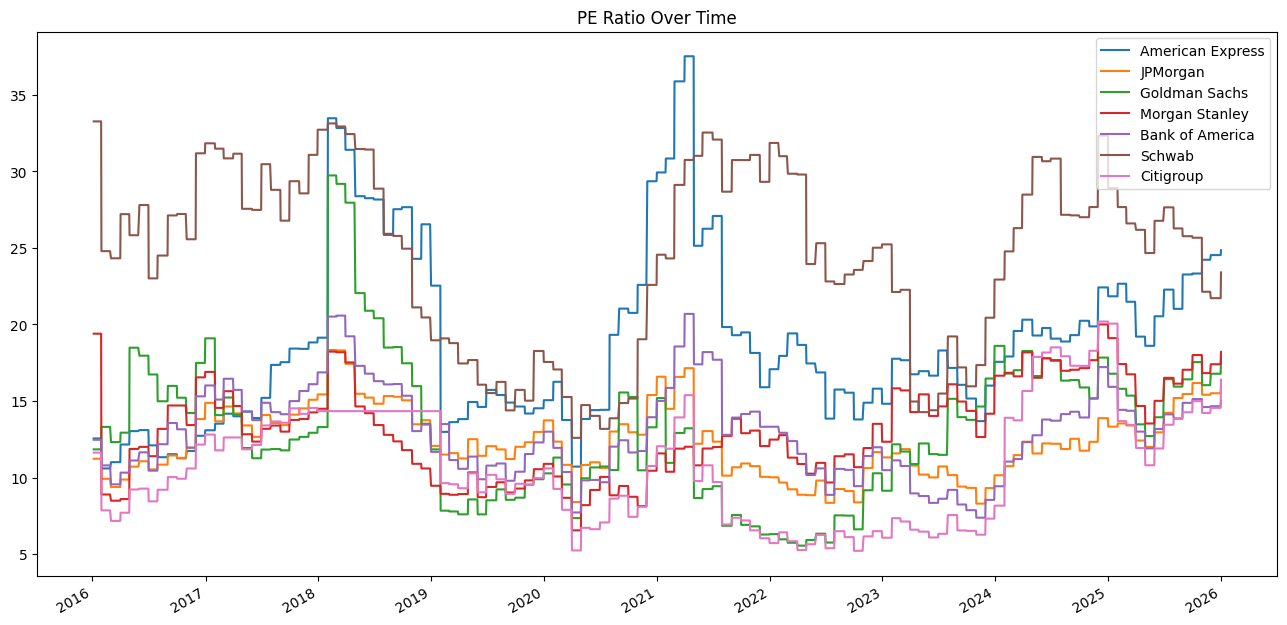

In [11]:
pe_ratios.plot(figsize=(16,8), title="PE Ratio Over Time")
plt.show()

In [12]:
mean_pe = pe_ratios.mean()
mean_pe.sort_values()

Citigroup           10.776876
JPMorgan            12.336862
Bank of America     12.965473
Goldman Sachs       13.082258
Morgan Stanley      13.135662
American Express    18.793673
Schwab              24.520420
dtype: float64

In [ ]:
history = qb.history(symbols, datetime(2016, 1, 1), datetime(2026, 1, 1), Resolution.DAILY).close.unstack(level=0)
history.columns = ["American Express", "JPMorgan", "Goldman Sachs", "Morgan Stanley", "Bank of America", "Schwab", "Citigroup"]
history.head()

,American Express,JPMorgan,Goldman Sachs,Morgan Stanley,Bank of America,Schwab,Citigroup
time,,,,,,,
2016-01-04 16:00:00,58.447581,13.112288,37.995030,143.606902,48.454747,23.585707,28.109307
2016-01-05 16:00:00,57.548254,13.112288,37.794392,141.134276,48.485179,23.435861,28.021411
2016-01-06 16:00:00,55.950174,12.840945,37.244493,137.688812,47.785251,22.851463,27.063339
2016-01-07 16:00:00,55.446432,12.370083,35.342140,133.456973,45.852843,21.712636,25.639415
2016-01-08 16:00:00,55.264042,12.130662,34.279498,132.905699,44.825776,21.263099,25.489991


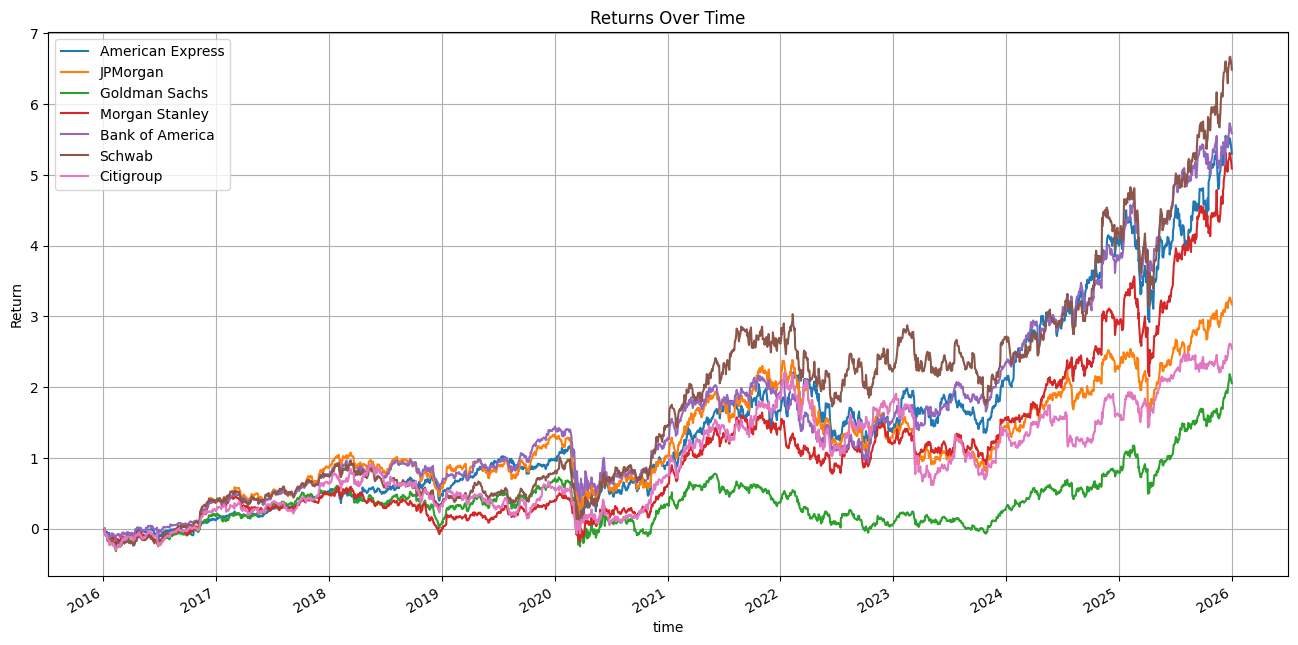

In [ ]:
returns_over_time = ((history.pct_change()[1:] + 1).cumprod() - 1)
returns_over_time.plot(figsize=(16,8), title="Returns Over Time")
plt.grid()
plt.ylabel("Return")
plt.show()

In [ ]:
np.corrcoef(returns_over_time.tail(1), mean_pe)

array([[1.        , 0.70965268],
       [0.70965268, 1.        ]])

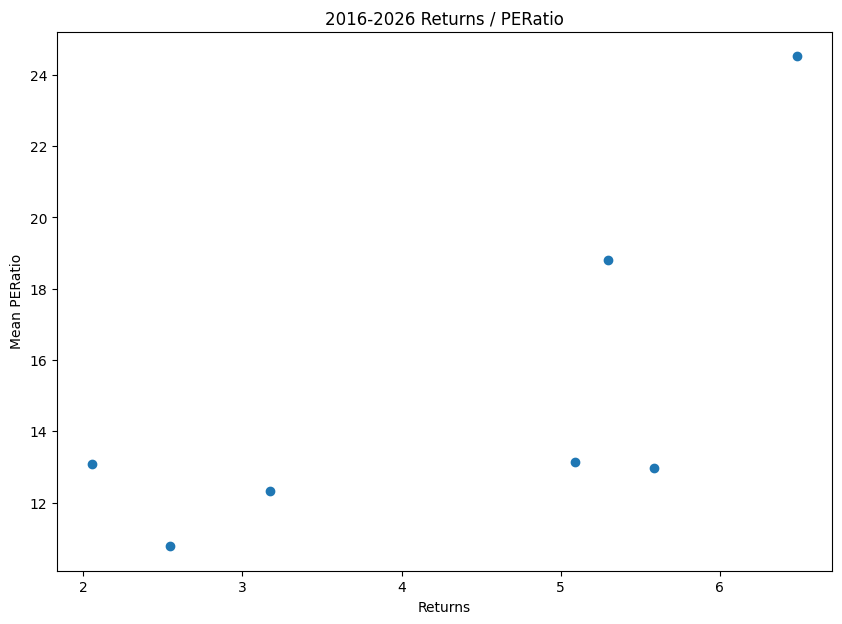

In [20]:
plt.figure(figsize=(10,7))
plt.scatter(returns_over_time.tail(1), mean_pe)
plt.title("2016-2026 Returns / PERatio")
plt.xlabel("Returns")
plt.ylabel("Mean PERatio")
plt.show()

In [ ]:
bac = qb.add_option("BAC")
bac.set_filter(-5, 5, timedelta(20), timedelta(50))

In [ ]:
option_history = qb.get_option_history(bac.symbol, datetime(2016, 1, 1), datetime(2016, 1, 10))
print(option_history.get_strikes())
print(option_history.get_expiry_dates())
option_history.get_all_data()

[13.0, 13.5, 14.0, 14.5, 15.0, 15.5, 16.0, 16.5, 17.0, 17.5, 18.0, 18.5, 19.0]
[datetime.datetime(2016, 1, 29, 0, 0), datetime.datetime(2016, 2, 5, 0, 0), datetime.datetime(2016, 2, 12, 0, 0), datetime.datetime(2016, 2, 19, 0, 0), datetime.datetime(2016, 2, 26, 0, 0)]


askclose  \
expiry              strike type symbol                           time                            
2016-01-29 00:00:00 14.5   Call NB W7MRNZUFKRNQ|NB R735QTJ8XC9X  2016-01-04 09:31:00      2.06   
                                                                 2016-01-04 09:32:00      2.06   
                                                                 2016-01-04 09:33:00      2.06   
                                                                 2016-01-04 09:34:00      2.09   
                                                                 2016-01-04 09:35:00      2.09   
...                                                                                        ...   
2016-02-26 00:00:00 18.0   Put  NB 307ICC1HCXCFA|NB R735QTJ8XC9X 2016-01-08 15:56:00      2.89   
                                                                 2016-01-08 15:57:00      2.91   
                                                                 2016-01-08 15:58:00      2.93   
                                                                 2016-01-08 15:59:00      2.93   
                                                                 2016-01-08 16:00:00      2.93   

                                                                                      askhigh  \
expiry              strike type symbol                           time                           
2016-01-29 00:00:00 14.5   Call NB W7MRNZUFKRNQ|NB R735QTJ8XC9X  2016-01-04 09:31:00     2.07   
                                                                 2016-01-04 09:32:00     2.06   
                                                                 2016-01-04 09:33:00     2.06   
                                                                 2016-01-04 09:34:00     2.09   
                                                                 2016-01-04 09:35:00     2.09   
...                                                                                       ...   
2016-02-26 00:00:00 18.0   Put  NB 307ICC1HCXCFA|NB R735QTJ8XC9X 2016-01-08 15:56:00     2.89   
                                                                 2016-01-08 15:57:00     2.91   
                                                                 2016-01-08 15:58:00     2.93   
                                                                 2016-01-08 15:59:00     2.93   
                                                                 2016-01-08 16:00:00     2.93   

                                                                                      asklow  \
expiry              strike type symbol                           time                          
2016-01-29 00:00:00 14.5   Call NB W7MRNZUFKRNQ|NB R735QTJ8XC9X  2016-01-04 09:31:00    2.04   
                                                                 2016-01-04 09:32:00    2.06   
                                                                 2016-01-04 09:33:00    2.06   
                                                                 2016-01-04 09:34:00    2.06   
                                                                 2016-01-04 09:35:00    2.09   
...                                                                                      ...   
2016-02-26 00:00:00 18.0   Put  NB 307ICC1HCXCFA|NB R735QTJ8XC9X 2016-01-08 15:56:00    2.89   
                                                                 2016-01-08 15:57:00    2.89   
                                                                 2016-01-08 15:58:00    2.91   
                                                                 2016-01-08 15:59:00    2.93   
                                                                 2016-01-08 16:00:00    2.93   

                                                                                      askopen  \
expiry              strike type symbol                           time                           
2016-01-29 00:00:00 14.5   Call NB W7MRNZUFKRNQ|NB R735QTJ8XC9X  2016-01-04 09:31:00     2.04   
         

<Axes: title={'center': 'BAC Bollinger Bands'}>

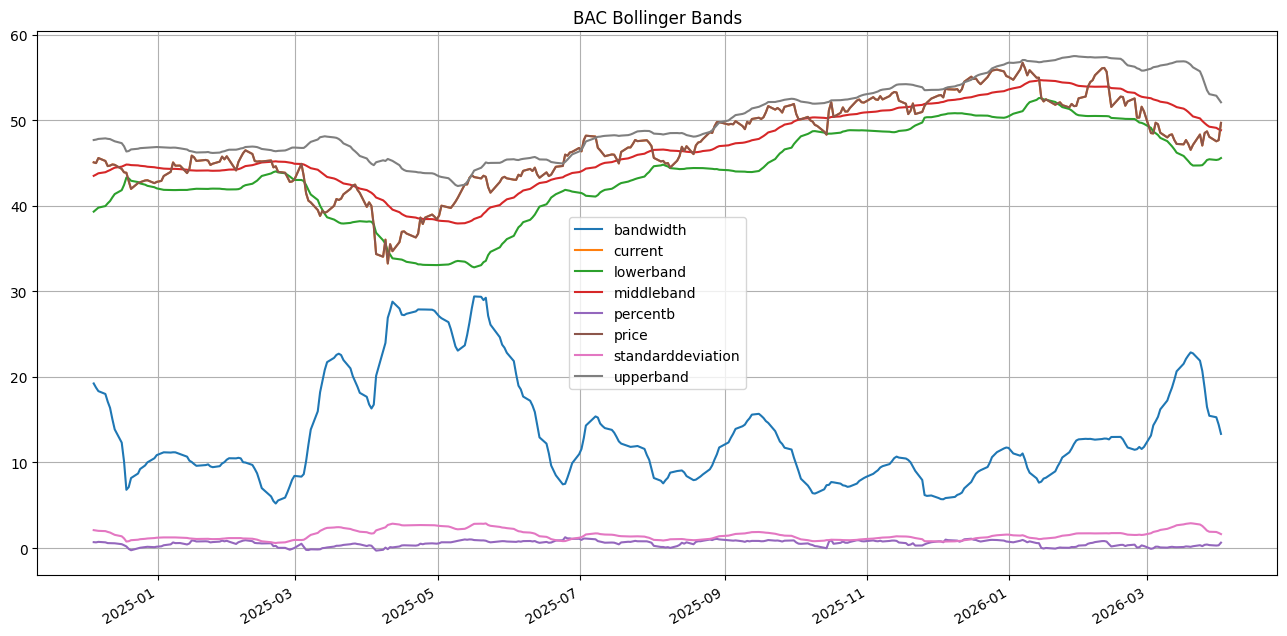

In [24]:
bb = BollingerBands(30, 2)
bbdf = qb.indicator(bb, "BAC", 360, Resolution.DAILY, Field.OPEN)
bbdf.plot(figsize=(16,8), title="BAC Bollinger Bands", grid=1)

<Axes: title={'center': 'BAC Bollinger Bands'}>

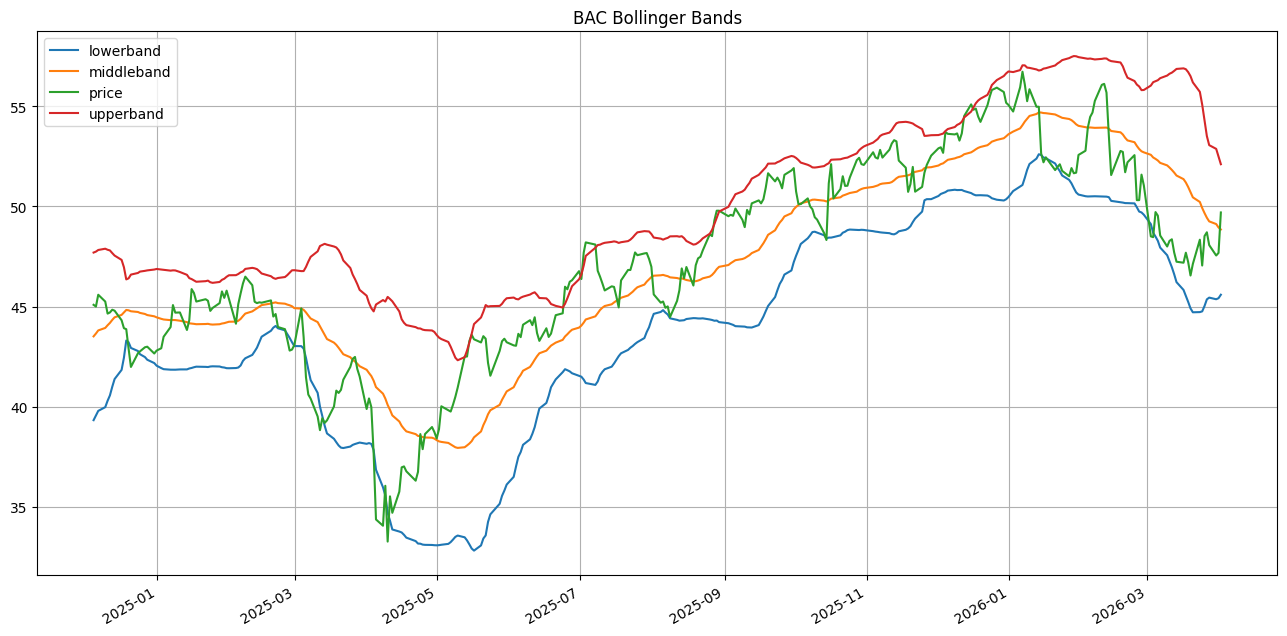

In [31]:
bbdf[["lowerband", "middleband", "price", "upperband"]].plot(figsize=(16,8), title="BAC Bollinger Bands", grid=1)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
history = qb.history(qb.symbol("BAC"), 60, Resolution.DAILY)

In [34]:
history = history.reset_index(level=0, drop=True)
prices = list(history["close"])

In [35]:
train_X = np.asarray(bbdf["middleband"][-60:-30]).reshape(30, 1)
train_Y = prices[:30]
reg = LinearRegression()
reg.fit(train_X, train_Y)

LinearRegression()

In [36]:
test_X = np.asarray(bbdf["middleband"][-60:]).reshape(60, 1)
prices_pred = reg.predict(test_X)

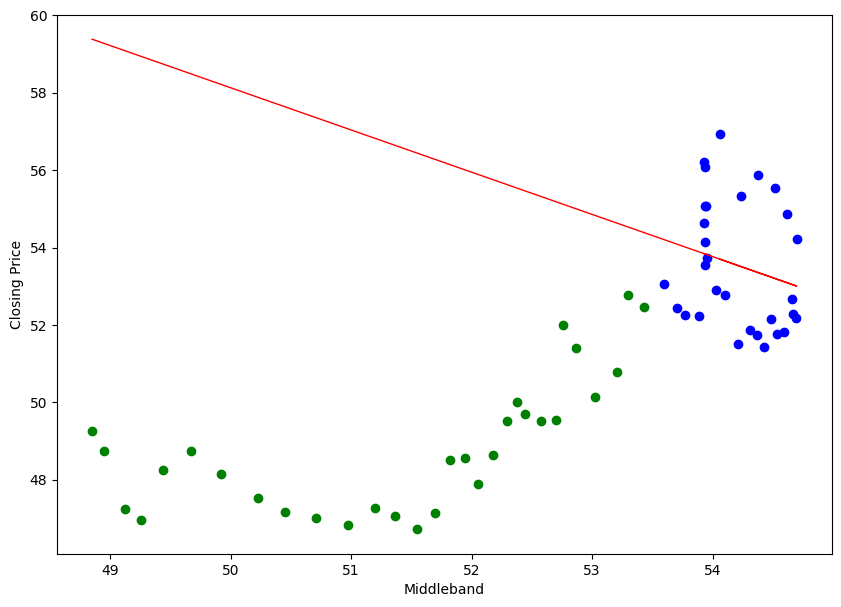

In [37]:
plt.figure(figsize=(10,7))
plt.scatter(bbdf["middleband"][-60:-30], prices[:30], color='blue')
plt.scatter(bbdf["middleband"][-30:], prices[30:60], color='green')

plt.plot(bbdf["middleband"][-60:], prices_pred, color='red', linewidth=1)
plt.xlabel("Middleband")
plt.ylabel("Closing Price")
plt.show()